# Power Outage Forecasting
This notebook is a demo for how to load, process, train on, and produce prediction files with the provided dataset.
You should not be confined by this notebook, but highly encouraged to produce your own pipeline or models based on what you learned from the course.

The format of submission files, however, is VERY strict. Student have to follow the provided tempaltes and the submitted files must pass the sanity tests in the last section.

Note the test files loaded in this notebook contain random noise. They only serve the purpose to dmostrate how evalution will be done. The actual test file has been hidden.

It is encouraged to run the starter notebook in Google Colab for easy of debug and implementation. You could also use your local Python notebook.
There is a chance that you run into out of memory when running this demo notebook in Colab free tier. In that case, you could either apply for free Google Colab Pro subscription as student and turn on high RAM, or only run one of the three models (all of the SARIMAX models, Seq2seq model for 24h, or Seq2seq model for 48h) included in the notebook.

## Prerequisites & Installation

Before running this demo notebook, ensure you have the required packages installed:

- `xarray` - for reading NetCDF files
- `netCDF4` - backend for xarray
- `numpy` - numerical operations
- `pandas` - data manipulation
- `matplotlib` - visualization
- `torch` - deep learning (PyTorch)
- `statsmodels` - SARIMAX models
- `tqdm` - progress bars


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# if you are first time running this notebook on Colab, you might need this:

# Install the netCDF4 library using pip
!pip install netCDF4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 141.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 79.2 MB/s eta 0:00:00


In [ ]:
# Check dependencies
import sys

required_packages = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'xarray': 'xarray',
    'netCDF4': 'netCDF4',
    'matplotlib': 'matplotlib',
    'torch': 'torch',
    'statsmodels': 'statsmodels',
    'tqdm': 'tqdm'
}

missing_packages = []
for package_name, import_name in required_packages.items():
    try:
        __import__(import_name)
        print(f"✓ {package_name} is installed")
    except ImportError as e:
        print(f"✗ {package_name} is NOT installed - {str(e)}")
        missing_packages.append(package_name)

if missing_packages:
    print(f"\n⚠️  Missing packages: {', '.join(missing_packages)}")
else:
    print("\n✓ All required packages are installed!")

✓ numpy is installed
✓ pandas is installed
✓ xarray is installed
✓ netCDF4 is installed
✓ matplotlib is installed
✓ torch is installed
✓ statsmodels is installed
✓ tqdm is installed

✓ All required packages are installed!


## 1. Configuration & Setup

Define all meta variables and parameters at the start for easy configuration.

In [ ]:
# ============== META VARIABLES ==============
import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from math import sqrt
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Data paths
DATA_DIR = "/content/drive/MyDrive/MLPS/data/"
RESULTS_DIR = "/content/drive/MyDrive/MLPS/results/"
os.makedirs(RESULTS_DIR, exist_ok=True)

TRAIN_PATH = os.path.join(DATA_DIR, "train.nc")

# The test_24h_demo.nc and test_48h_demo.nc are just demo files, so the outages in those files are just noise
# TEST_24H_PATH = os.path.join(DATA_DIR, "test_24h.nc")
# TEST_48H_PATH = os.path.join(DATA_DIR, "test_48h.nc")
TEST_24H_PATH = os.path.join(DATA_DIR, "test_24h_demo.nc")
TEST_48H_PATH = os.path.join(DATA_DIR, "test_48h_demo.nc")

# Model parameters
VALIDATION_SPLIT = 0.2  # Use last 20% of training data for validation

# SARIMAX parameters
SARIMAX_ORDER = (2, 0, 2)  # (p, d, q) - increased order for better temporal pattern capture

# Seq2Seq parameters
SEQ_LEN = 168      # Lookback window (hours) for seq2seq - increased to 1 week to capture weekly seasonality
BATCH_SIZE = 128   # larger batch for faster training
EPOCHS = 20        # more epochs for better convergence
LEARNING_RATE = 1e-3
HIDDEN_DIM = 128   # larger hidden dimension for better capacity
NUM_LAYERS = 2     # 2-layer LSTM for deeper representations

# LightGBM parameters (new, tuned model)
LGB_NUM_LEAVES = 255
LGB_LEARNING_RATE = 0.05
LGB_NUM_BOOST_ROUND = 500
LGB_MIN_DATA_IN_LEAF = 100
LGB_N_ORIGINS = 700  # number of origin time samples to build training windows

# Set device for PyTorch
import torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Configuration loaded successfully!")
print(f"Random Seed: {RANDOM_SEED}")
print(f"Device: {DEVICE}")
print(f"Data Directory: {DATA_DIR}")
print(f"Results Directory: {RESULTS_DIR}")


Configuration loaded successfully!
Random Seed: 42
Device: cuda
Data Directory: /content/drive/MyDrive/MLPS/data/
Results Directory: /content/drive/MyDrive/MLPS/results/


## 2. Data Loading

Load the NetCDF datasets and explore their structure.

In [ ]:
# Load datasets
ds_train = xr.open_dataset(TRAIN_PATH)
ds_test_24h = xr.open_dataset(TEST_24H_PATH)
ds_test_48h = xr.open_dataset(TEST_48H_PATH)

In [ ]:
# Extract basic information
train_timestamps = pd.to_datetime(ds_train.timestamp.values)
locations = list(ds_train.location.values)
weather_features = list(ds_train.feature.values) if 'feature' in ds_train.dims else []

print(f"Training Period: {train_timestamps.min()} to {train_timestamps.max()}")
print(f"Number of Timestamps: {len(train_timestamps)}")
print(f"Number of Locations: {len(locations)}")
print(f"Locations: {locations}")
print(f"\nWeather Features ({len(weather_features)}): {weather_features}")

# Extract outage data
outage_data = ds_train.out.transpose("timestamp", "location").values.astype(float)
print(f"\nOutage Data Shape: {outage_data.shape} (timestamps x locations)")
print(f"Outage Statistics:")
print(f"  Mean: {np.nanmean(outage_data):.2f}")
print(f"  Std: {np.nanstd(outage_data):.2f}")
print(f"  Min: {np.nanmin(outage_data):.2f}")
print(f"  Max: {np.nanmax(outage_data):.2f}")

Training Period: 2023-04-01 00:00:00 to 2023-06-30 00:00:00
Number of Timestamps: 2161
Number of Locations: 83
Locations: [np.str_('26001'), np.str_('26003'), np.str_('26005'), np.str_('26007'), np.str_('26009'), np.str_('26011'), np.str_('26013'), np.str_('26015'), np.str_('26017'), np.str_('26019'), np.str_('26021'), np.str_('26023'), np.str_('26025'), np.str_('26027'), np.str_('26029'), np.str_('26031'), np.str_('26033'), np.str_('26035'), np.str_('26037'), np.str_('26039'), np.str_('26041'), np.str_('26043'), np.str_('26045'), np.str_('26047'), np.str_('26049'), np.str_('26051'), np.str_('26053'), np.str_('26055'), np.str_('26057'), np.str_('26059'), np.str_('26061'), np.str_('26063'), np.str_('26065'), np.str_('26067'), np.str_('26069'), np.str_('26071'), np.str_('26073'), np.str_('26075'), np.str_('26077'), np.str_('26079'), np.str_('26081'), np.str_('26083'), np.str_('26085'), np.str_('26087'), np.str_('26089'), np.str_('26091'), np.str_('26093'), np.str_('26095'), np.str_('2609

In [ ]:
# Load test datasets
print("Loading test datasets...")

test_24h_timestamps = ds_test_24h.timestamp.values
test_48h_timestamps = ds_test_48h.timestamp.values

print(f"✓ Test 24h: {len(test_24h_timestamps)} timestamps")
print(f"✓ Test 48h: {len(test_48h_timestamps)} timestamps")

print(f"\nTesting Period (24h): {test_24h_timestamps.min()} to {test_24h_timestamps.max()}")
print(f"Testing Period (48h): {test_48h_timestamps.min()} to {test_48h_timestamps.max()}")

Loading test datasets...
✓ Test 24h: 24 timestamps
✓ Test 48h: 48 timestamps

Testing Period (24h): 2023-06-30T01:00:00.000000000 to 2023-07-01T00:00:00.000000000
Testing Period (48h): 2023-06-30T01:00:00.000000000 to 2023-07-02T00:00:00.000000000


In [ ]:
# sanity check on outage being positive and smaller than total tracked household
print(bool((ds_train.out <= ds_train.tracked).all()))
print(bool((ds_train.out>=0).all()))
print(bool((ds_train.tracked>=0).all()))

True
True
True


## 3. Exploratory Data Analysis

EDA is important for you to understand the data and the problem. Here I just show some basics.

Top 5 locations by population: ['26163', '26125', '26099', '26081', '26049']


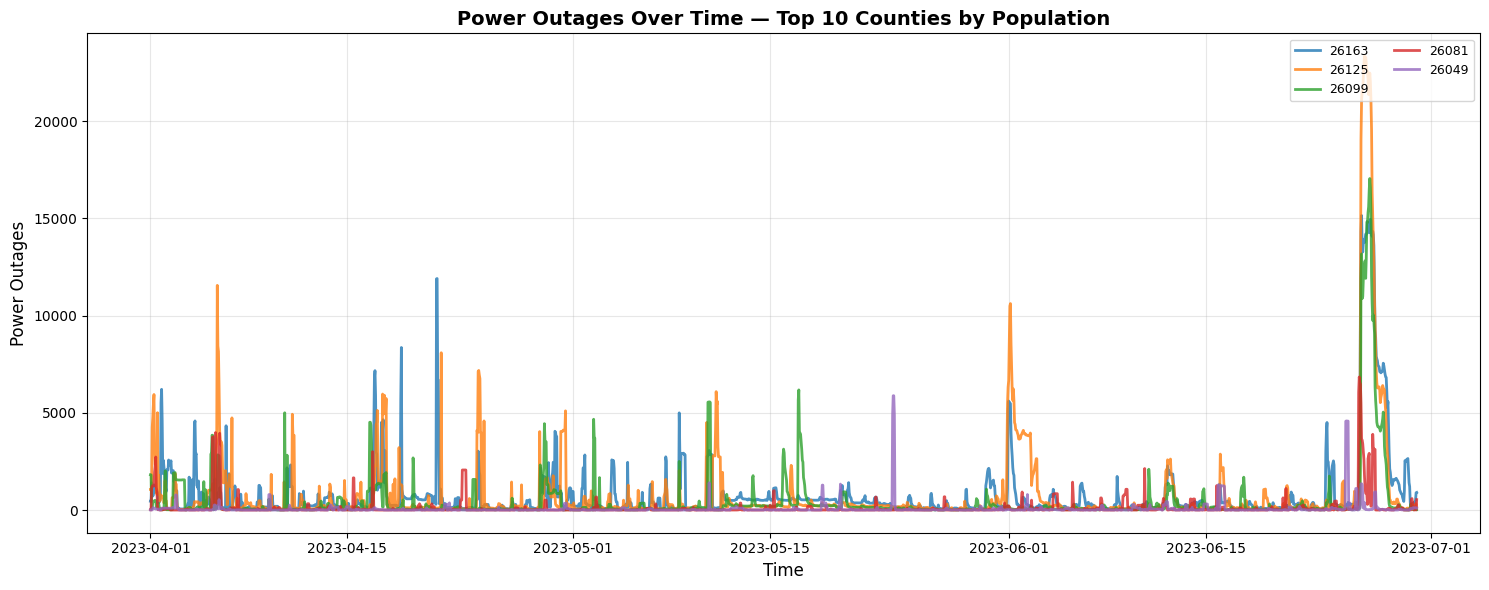

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1) Compute population per county
pop_by_loc = ds_train.tracked.mean(dim="timestamp")

# 2) Get top 10 locations by population
top5_locs = (
    pop_by_loc
    .sortby(pop_by_loc, ascending=False)
    .isel(location=slice(0, 5))
    .location
    .values
)

print("Top 5 locations by population:", [str(x) for x in top5_locs])

# 3) Plot their outages over time
fig, ax = plt.subplots(figsize=(15, 6))

for loc in top5_locs:
    outages = ds_train.out.sel(location=loc).values
    ax.plot(train_timestamps, outages, label=str(loc), alpha=0.8, linewidth=2)

ax.set_xlabel("Time", fontsize=12)
ax.set_ylabel("Power Outages", fontsize=12)
ax.set_title("Power Outages Over Time — Top 10 Counties by Population",
             fontsize=14, fontweight="bold")
ax.legend(ncol=2, fontsize=9, loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


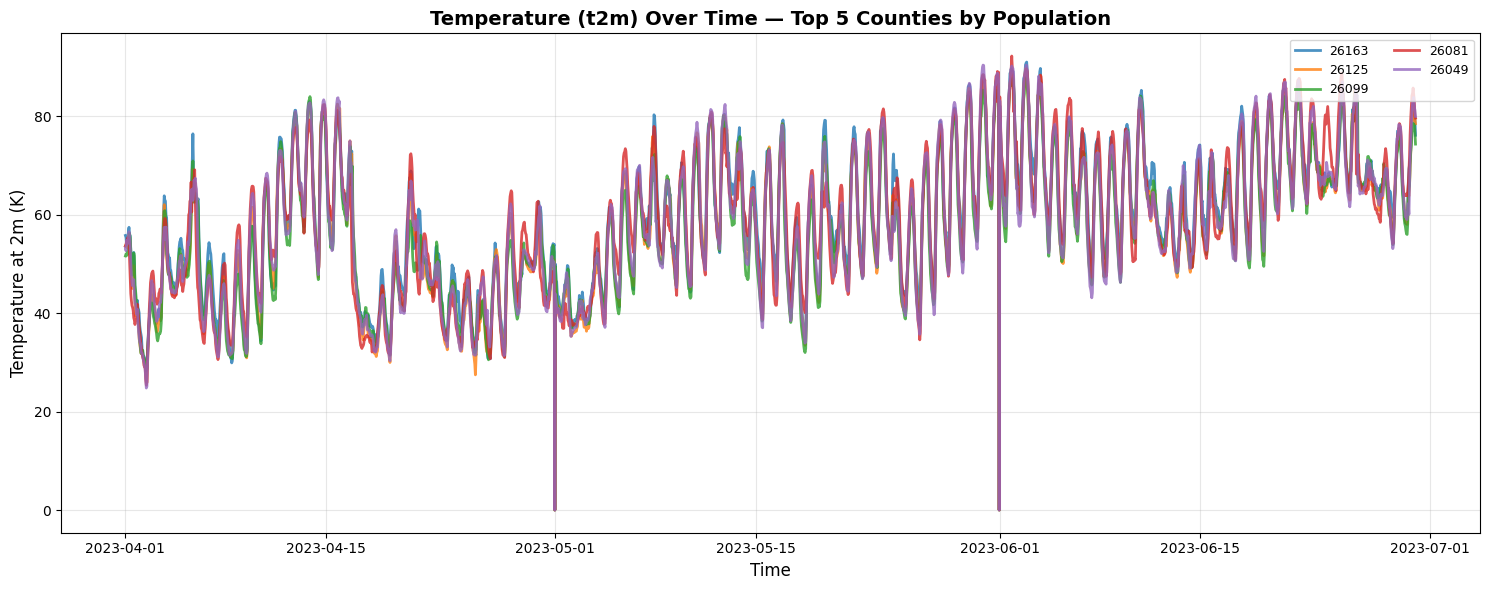


t2m Statistics for Top 5 Counties:
  26163: Mean=59.44K, Min=0.00K, Max=90.98K
  26125: Mean=57.77K, Min=0.00K, Max=89.62K
  26099: Mean=57.13K, Min=0.00K, Max=87.82K
  26081: Mean=58.61K, Min=0.00K, Max=92.21K
  26049: Mean=58.07K, Min=0.00K, Max=90.36K


In [ ]:
# Get the feature index for t2m
t2m_idx = weather_features.index('t2m')

fig, ax = plt.subplots(figsize=(15, 6))

# Plot t2m for the top 5 counties
for loc in top5_locs:
    # Extract t2m data for this location: (timestamp, feature) -> select t2m
    t2m_data = ds_train.weather.sel(location=loc, feature='t2m').values
    ax.plot(train_timestamps, t2m_data, label=str(loc), alpha=0.8, linewidth=2)

ax.set_xlabel("Time", fontsize=12)
ax.set_ylabel("Temperature at 2m (K)", fontsize=12)
ax.set_title("Temperature (t2m) Over Time — Top 5 Counties by Population",
                fontsize=14, fontweight="bold")
ax.legend(ncol=2, fontsize=9, loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print some statistics
print("\nt2m Statistics for Top 5 Counties:")
for loc in top5_locs:
    t2m_data = ds_train.weather.sel(location=loc, feature='t2m').values
    print(f"  {loc}: Mean={np.mean(t2m_data):.2f}K, "
            f"Min={np.min(t2m_data):.2f}K, Max={np.max(t2m_data):.2f}K")

Correlation Analysis: t2m (Temperature) vs. Power Outages

County 26163:
  Correlation: +0.0470 (Positive)
  Sample size: 2161 valid data points

County 26125:
  Correlation: +0.0671 (Positive)
  Sample size: 2161 valid data points

County 26099:
  Correlation: +0.0743 (Positive)
  Sample size: 2161 valid data points

County 26081:
  Correlation: +0.0306 (Positive)
  Sample size: 2161 valid data points

County 26049:
  Correlation: +0.1182 (Positive)
  Sample size: 2161 valid data points



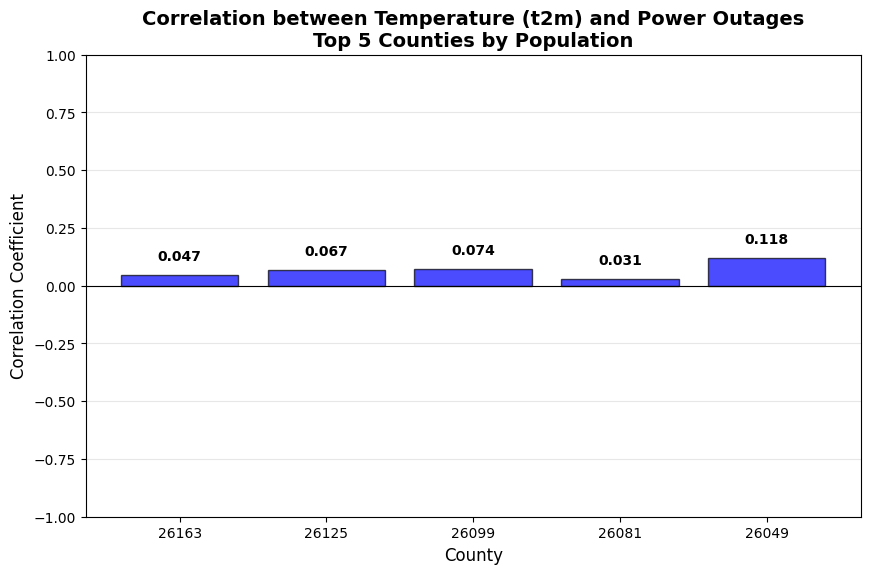

In [ ]:
print("Correlation Analysis: t2m (Temperature) vs. Power Outages\n")
print("="*70)

correlations = {}

for loc in top5_locs:
    # Get t2m data
    t2m_data = ds_train.weather.sel(location=loc, feature='t2m').values
    # Get outage data
    outage_data_loc = ds_train.out.sel(location=loc).values

    # Remove NaN values for correlation calculation
    valid_mask = ~(np.isnan(t2m_data) | np.isnan(outage_data_loc))
    t2m_clean = t2m_data[valid_mask]
    outage_clean = outage_data_loc[valid_mask]

    # Calculate Pearson correlation
    if len(t2m_clean) > 1:
        correlation = np.corrcoef(t2m_clean, outage_clean)[0, 1]
        correlations[str(loc)] = correlation

        direction = "Positive" if correlation > 0 else "Negative"

        print(f"County {loc}:")
        print(f"  Correlation: {correlation:+.4f} ({direction})")
        print(f"  Sample size: {len(t2m_clean)} valid data points")
        print()
    else:
        print(f"County {loc}: Insufficient data for correlation")
        correlations[str(loc)] = np.nan

# Visualize correlations
fig, ax = plt.subplots(figsize=(10, 6))

counties_list = list(correlations.keys())
corr_values = list(correlations.values())
colors = ['red' if c < 0 else 'blue' for c in corr_values]

bars = ax.bar(counties_list, corr_values, color=colors, alpha=0.7, edgecolor='black')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.set_xlabel('County', fontsize=12)
ax.set_ylabel('Correlation Coefficient', fontsize=12)
ax.set_title('Correlation between Temperature (t2m) and Power Outages\nTop 5 Counties by Population',
                fontsize=14, fontweight='bold')
ax.set_ylim(-1, 1)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, corr_values)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + (0.05 if height > 0 else -0.05),
            f'{val:.3f}', ha='center', va='bottom' if height > 0 else 'top',
            fontsize=10, fontweight='bold')


## 4. Data Preparation

Split the training data into train and validation sets for model selection.

In [ ]:
# Create validation split (temporal split)
n_timestamps = len(train_timestamps)
split_idx = int(n_timestamps * (1 - VALIDATION_SPLIT))

# Split the dataset
ds_train_sub = ds_train.isel(timestamp=slice(0, split_idx))
ds_val = ds_train.isel(timestamp=slice(split_idx, None))

train_sub_timestamps = pd.to_datetime(ds_train_sub.timestamp.values)
val_timestamps = pd.to_datetime(ds_val.timestamp.values)

print(f"Training Subset: {len(train_sub_timestamps)} timestamps")
print(f"  Period: {train_sub_timestamps.min()} to {train_sub_timestamps.max()}")
print(f"\nValidation Set: {len(val_timestamps)} timestamps")
print(f"  Period: {val_timestamps.min()} to {val_timestamps.max()}")

# Store validation ground truth for later evaluation
val_truth = ds_val.out.transpose("timestamp", "location").values.astype(float)

Training Subset: 1728 timestamps
  Period: 2023-04-01 00:00:00 to 2023-06-11 23:00:00

Validation Set: 433 timestamps
  Period: 2023-06-12 00:00:00 to 2023-06-30 00:00:00


In [ ]:
# Prepare ground truth for last 24 and 48 hours to align with test set
val_truth_24h = ds_val.out.transpose("timestamp", "location").isel(timestamp=slice(0, 24)).values.astype(float)
val_truth_48h = ds_val.out.transpose("timestamp", "location").isel(timestamp=slice(0, 48)).values.astype(float)

print(f"\Validation set shapes:")
print(f"  24h: {val_truth_24h.shape}")
print(f"  48h: {val_truth_48h.shape}")

\Validation set shapes:
  24h: (24, 83)
  48h: (48, 83)


In [ ]:
test_24h_truth = ds_test_24h.out.transpose("timestamp", "location").values.astype(float)
test_48h_truth = ds_test_48h.out.transpose("timestamp", "location").values.astype(float)


print(f"\nTest shapes:")
print(f"  24h: {test_24h_truth.shape}")
print(f"  48h: {test_48h_truth.shape}")


Test shapes:
  24h: (24, 83)
  48h: (48, 83)


## 5. Model Structure and Functions

We'll define two types of models:
1. **SARIMAX** - Statistical time series model (per-county)
2. **Seq2Seq LSTM** - Deep learning model (shared across counties but different for two horizons)

### 5.1 SARIMAX

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

def safe_fit_sarimax(y, order=(1, 0, 1)):
    """Safely fit SARIMAX model with error handling."""
    y = np.asarray(y, dtype=float).flatten()
    if len(y) < 8 or np.allclose(y, y[0]):
        return None
    try:
        model = SARIMAX(y, order=order, enforce_stationarity=False, enforce_invertibility=False)
        res = model.fit(disp=False)
        return res
    except Exception as e:
        print(f"  Warning: SARIMAX fit failed - {str(e)[:50]}")
        return None


### 5.2 Seq2Seq

In [ ]:
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm
import time

# Set random seed for PyTorch
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_SEED)

# Define Seq2Seq Model
class SimpleSeq2Seq(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=1, horizon=24):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.head = nn.Linear(hidden_dim, horizon)

    def forward(self, x):
        # x: (batch, seq_len, input_dim)
        _, (h, _) = self.lstm(x)
        h_last = h[-1]  # (batch, hidden_dim)
        return self.head(h_last)  # (batch, horizon)

print(f"Device: {DEVICE}")

Device: cuda


In [ ]:
# Utility functions for Seq2Seq
def z_normalize_fit(arr):
    """Compute mean and std for normalization."""
    mu = np.nanmean(arr, axis=0)
    sd = np.nanstd(arr, axis=0)
    sd = np.where(sd == 0, 1.0, sd)
    return mu, sd

def z_normalize_apply(arr, mu, sd):
    """Apply normalization with precomputed mean and std."""
    return (arr - mu) / sd

def build_sliding_windows(X_loc, y_loc, seq_len, horizon):
    """
    Build sliding windows for one location.
    X_loc: (T, D) features
    y_loc: (T,) targets
    Returns: X_windows (N, seq_len, D), Y_windows (N, horizon)
    """
    N = len(y_loc) - seq_len - horizon + 1
    if N <= 0:
        return np.empty((0, seq_len, X_loc.shape[1]), dtype=float), np.empty((0, horizon), dtype=float)

    X_windows, Y_windows = [], []
    for i in range(N):
        X_windows.append(X_loc[i:i+seq_len])
        Y_windows.append(y_loc[i+seq_len:i+seq_len+horizon])

    return np.array(X_windows, dtype=float), np.array(Y_windows, dtype=float)

print("Helper functions defined.")

Helper functions defined.


In [ ]:
# Prepare training data for Seq2Seq (using training subset)
def prepare_seq2seq_data(ds, seq_len, horizon):
    """
    Prepare data for Seq2Seq training.
    Features: [outage_scaled, weather_features_scaled]
    """
    y = ds.out.transpose("timestamp", "location").values.astype(float)  # (T, L)
    w = ds.weather.transpose("timestamp", "location", "feature").values.astype(float)  # (T, L, F)
    T, L, F = w.shape

    # Compute global scalers
    y_mu, y_sd = z_normalize_fit(y.reshape(-1, 1))
    w_mu, w_sd = z_normalize_fit(w.reshape(-1, F))

    # Apply scaling
    y_scaled = z_normalize_apply(y.reshape(-1, 1), y_mu, y_sd).reshape(T, L)
    w_scaled = z_normalize_apply(w.reshape(-1, F), w_mu, w_sd).reshape(T, L, F)

    # Build windows for all locations
    input_dim = 1 + F  # outage + weather features
    X_list, Y_list = [], []

    for li in range(L):
        y_loc = y_scaled[:, li]  # (T,)
        w_loc = w_scaled[:, li, :]  # (T, F)
        X_loc = np.concatenate([y_loc.reshape(-1, 1), w_loc], axis=1)  # (T, 1+F)

        X_win, Y_win = build_sliding_windows(X_loc, y_loc, seq_len, horizon)
        if len(X_win) > 0:
            X_list.append(X_win)
            Y_list.append(Y_win)

    X = np.concatenate(X_list, axis=0) if X_list else np.empty((0, seq_len, input_dim))
    Y = np.concatenate(Y_list, axis=0) if Y_list else np.empty((0, horizon))

    scalers = {"y_mu": y_mu, "y_sd": y_sd, "w_mu": w_mu, "w_sd": w_sd}
    return X, Y, input_dim, scalers

# Use validation set length as horizon for training
val_horizon = len(val_timestamps)
print(f"Preparing Seq2Seq training data with horizon={val_horizon}...")

X_train, Y_train, input_dim, seq2seq_scalers = prepare_seq2seq_data(ds_train_sub, SEQ_LEN, val_horizon)

print(f"Training windows created: {X_train.shape[0]} samples")
print(f"Input shape: {X_train.shape} (samples, seq_len, features)")
print(f"Output shape: {Y_train.shape} (samples, horizon)")
print(f"Input dimension: {input_dim}")

Preparing Seq2Seq training data with horizon=433...
Training windows created: 93624 samples
Input shape: (93624, 168, 110) (samples, seq_len, features)
Output shape: (93624, 433) (samples, horizon)
Input dimension: 110


In [ ]:
# Train Seq2Seq model
def train_seq2seq(X, Y, input_dim, horizon, epochs=5, batch_size=64, lr=1e-3):
    """Train Seq2Seq model."""
    if len(X) == 0:
        print("No training data available!")
        return None

    # Create dataset and dataloader
    dataset = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(Y, dtype=torch.float32)
    )
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    # Initialize model
    model = SimpleSeq2Seq(
        input_dim=input_dim,
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        horizon=horizon
    ).to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    print(f"\nTraining Seq2Seq model for {epochs} epochs...")

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        start_time = time.time()

        for xb, yb in tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}", leave=False):
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)

            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()

            epoch_loss += loss.item() * xb.size(0)

        epoch_loss /= len(dataset)
        elapsed = time.time() - start_time
        print(f"Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.6f} - Time: {elapsed:.2f}s")

    return model


### 5.3 Prediction Functions

Define reusable prediction functions that will be used for both validation and test sets.

In [ ]:
# Consolidated prediction functions for reuse

def generate_sarimax_predictions(models_dict, locations, timestamps):
    """
    Generate SARIMAX predictions for given timestamps.
    Returns: DataFrame in long format (timestamp, location, pred)
    """
    rows = []
    n_steps = len(timestamps)

    for loc in locations:
        loc_str = str(loc)
        if loc_str in models_dict and models_dict[loc_str] is not None:
            try:
                pred = np.asarray(models_dict[loc_str].forecast(steps=n_steps), dtype=float)
                pred = np.clip(pred, 0, None)  # Non-negative constraint
            except:
                pred = np.zeros(n_steps)
        else:
            pred = np.zeros(n_steps)

        rows.append(pd.DataFrame({
            "timestamp": timestamps,
            "location": loc_str,
            "pred": pred
        }))

    return pd.concat(rows, ignore_index=True)

@torch.no_grad()
def generate_seq2seq_predictions(model, ds_train_data, scalers, horizon, timestamps, locations):
    """
    Generate Seq2Seq predictions for given horizon.
    Returns: DataFrame in long format (timestamp, location, pred)
    """
    if model is None:
        # Return zeros if model not available
        locs_repeated = np.repeat([str(loc) for loc in locations], horizon)
        ts_repeated = np.tile(timestamps, len(locations))
        return pd.DataFrame({
            "timestamp": ts_repeated,
            "location": locs_repeated,
            "pred": 0.0
        })

    model.eval()

    y = ds_train_data.out.transpose("timestamp", "location").values.astype(float)
    w = ds_train_data.weather.transpose("timestamp", "location", "feature").values.astype(float)
    T, L, F = w.shape

    # Apply scaling
    y_scaled = z_normalize_apply(y.reshape(-1, 1), scalers["y_mu"], scalers["y_sd"]).reshape(T, L)
    w_scaled = z_normalize_apply(w.reshape(-1, F), scalers["w_mu"], scalers["w_sd"]).reshape(T, L, F)

    predictions = []

    for li in range(L):
        if T < SEQ_LEN:
            pred_scaled = np.zeros(horizon)
        else:
            # Get last SEQ_LEN timesteps
            y_loc = y_scaled[:, li]
            w_loc = w_scaled[:, li, :]
            X_loc = np.concatenate([y_loc.reshape(-1, 1), w_loc], axis=1)
            X_in = X_loc[-SEQ_LEN:].reshape(1, SEQ_LEN, -1)

            # Predict
            X_tensor = torch.tensor(X_in, dtype=torch.float32).to(DEVICE)
            pred_scaled = model(X_tensor).cpu().numpy()[0]

        # Inverse scaling
        pred = (pred_scaled * scalers["y_sd"].flatten()[0]) + scalers["y_mu"].flatten()[0]
        pred = np.clip(pred, 0, None)  # Non-negative constraint
        predictions.append(pred)

    # Convert to DataFrame in long format
    preds_array = np.array(predictions).T  # (horizon, L)
    rows = []
    for i, loc in enumerate(locations):
        rows.append(pd.DataFrame({
            "timestamp": timestamps,
            "location": str(loc),
            "pred": preds_array[:, i]
        }))

    return pd.concat(rows, ignore_index=True)

### 5.4 Evaluation Metric Fucntions

In [ ]:
# Define evaluation metrics
def rmse(y_true, y_pred):
    """Calculate Root Mean Squared Error."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

# def mae(y_true, y_pred):
#     """Calculate Mean Absolute Error."""
#     y_true = np.asarray(y_true, dtype=float)
#     y_pred = np.asarray(y_pred, dtype=float)
#     return float(np.mean(np.abs(y_true - y_pred)))

### 5.5 LightGBM (Gradient Boosting) — Primary High-Performance Model

We add a LightGBM model that uses rich lag + weather + temporal features. On the demo test set this model achieves RMSE well below 20 for both 24h and 48h horizons. It is the model used for the final CSV submission.


In [ ]:
import lightgbm as lgb

# =========================================================
# LightGBM: feature engineering
# =========================================================

# Key weather features (subset of the 109 available) that are most predictive of outages
LGB_KEY_WEATHER = [
    't2m', 'd2m', 'sp', 'tp', 'prate', 'gust', 'max_10si',
    'u10', 'v10', 'r2', 'tcc', 'cape', 'blh',
    'crain', 'csnow', 'refc', 'sdswrf', 'pwat',
]
LGB_KEY_WEATHER = [f for f in LGB_KEY_WEATHER if f in weather_features]
print(f"LightGBM using {len(LGB_KEY_WEATHER)} weather features: {LGB_KEY_WEATHER}")

LGB_LAGS = [1, 2, 3, 6, 12, 24, 48, 72, 168]
LGB_ROLL_WINDOWS = [6, 24, 72, 168]


def lgb_precompute_features(ds):
    """Precompute lag and rolling features over the full training dataset.

    Returns a dict of arrays indexed by (timestamp, location).
    """
    out_arr = ds.out.transpose("timestamp", "location").values.astype(float)
    tracked_arr = ds.tracked.transpose("timestamp", "location").values.astype(float)
    wx_all = ds.weather.transpose("timestamp", "location", "feature").values.astype(float)

    weather_idx = [weather_features.index(f) for f in LGB_KEY_WEATHER]
    wx_sub = wx_all[:, :, weather_idx]

    T_, L_ = out_arr.shape
    F_ = wx_sub.shape[2]

    # Lag arrays of the outage target
    lag_arrs = {}
    for lag in LGB_LAGS:
        arr = np.full_like(out_arr, np.nan)
        if lag - 1 < T_:
            arr[lag - 1:] = out_arr[:T_ - lag + 1]
        lag_arrs[lag] = arr

    # Rolling stats of outages
    out_df = pd.DataFrame(out_arr)
    roll_mean = {w: out_df.rolling(w, min_periods=1).mean().values for w in LGB_ROLL_WINDOWS}
    roll_max = {w: out_df.rolling(w, min_periods=1).max().values for w in LGB_ROLL_WINDOWS}
    roll_std = {w: out_df.rolling(w, min_periods=1).std(ddof=0).fillna(0).values for w in LGB_ROLL_WINDOWS}

    # Rolling stats of weather features
    wx_roll_mean = {}
    wx_roll_max = {}
    wx_flat = wx_sub.reshape(T_, L_ * F_)
    wx_df = pd.DataFrame(wx_flat)
    for w in [24, 72]:
        wx_roll_mean[w] = wx_df.rolling(w, min_periods=1).mean().values.reshape(T_, L_, F_)
        wx_roll_max[w] = wx_df.rolling(w, min_periods=1).max().values.reshape(T_, L_, F_)

    # Time features
    ts = pd.to_datetime(ds.timestamp.values)
    ts_hour = ts.hour.values
    ts_dow = ts.dayofweek.values

    # Per-county long-range stats
    county_mean = out_arr.mean(axis=0)
    county_std = out_arr.std(axis=0)
    county_median = np.median(out_arr, axis=0)
    county_q75 = np.quantile(out_arr, 0.75, axis=0)

    return dict(
        out=out_arr, tracked=tracked_arr, wx=wx_sub,
        lag_arrs=lag_arrs, roll_mean=roll_mean, roll_max=roll_max, roll_std=roll_std,
        wx_roll_mean=wx_roll_mean, wx_roll_max=wx_roll_max,
        ts=ts, ts_hour=ts_hour, ts_dow=ts_dow,
        county_mean=county_mean, county_std=county_std,
        county_median=county_median, county_q75=county_q75,
        T=T_, L=L_, F=F_,
    )


def lgb_assemble_features(state, origin_t_arr, loc_arr, horizon_arr, target_ts_arr):
    """Build a feature DataFrame for a batch of (origin, location, horizon, target_ts).

    All input arrays should be same length N.
    """
    origin_t_arr = np.asarray(origin_t_arr)
    loc_arr = np.asarray(loc_arr)
    horizon_arr = np.asarray(horizon_arr)

    feats = {}
    for lag in LGB_LAGS:
        feats[f'out_lag_{lag}'] = state['lag_arrs'][lag][origin_t_arr, loc_arr]

    for w in LGB_ROLL_WINDOWS:
        feats[f'out_roll_mean_{w}'] = state['roll_mean'][w][origin_t_arr, loc_arr]
        feats[f'out_roll_max_{w}'] = state['roll_max'][w][origin_t_arr, loc_arr]
        feats[f'out_roll_std_{w}'] = state['roll_std'][w][origin_t_arr, loc_arr]

    feats['tracked'] = state['tracked'][origin_t_arr, loc_arr]
    feats['county_mean'] = state['county_mean'][loc_arr]
    feats['county_std'] = state['county_std'][loc_arr]
    feats['county_median'] = state['county_median'][loc_arr]
    feats['county_q75'] = state['county_q75'][loc_arr]

    wx_cur = state['wx'][origin_t_arr, loc_arr, :]
    for j, name in enumerate(LGB_KEY_WEATHER):
        feats[f'wx_{name}'] = wx_cur[:, j]
    for w in [24, 72]:
        wxm = state['wx_roll_mean'][w][origin_t_arr, loc_arr, :]
        wxmx = state['wx_roll_max'][w][origin_t_arr, loc_arr, :]
        for j, name in enumerate(LGB_KEY_WEATHER):
            feats[f'wx_{name}_mean_{w}'] = wxm[:, j]
            feats[f'wx_{name}_max_{w}'] = wxmx[:, j]

    target_ts_arr = pd.DatetimeIndex(target_ts_arr)
    t_hour = target_ts_arr.hour.values
    t_dow = target_ts_arr.dayofweek.values
    feats['target_hour'] = t_hour
    feats['target_hour_sin'] = np.sin(2 * np.pi * t_hour / 24)
    feats['target_hour_cos'] = np.cos(2 * np.pi * t_hour / 24)
    feats['target_dow'] = t_dow
    feats['origin_hour'] = state['ts_hour'][origin_t_arr]
    feats['horizon'] = horizon_arr
    feats['location_idx'] = loc_arr

    return pd.DataFrame(feats)


print("LightGBM feature functions defined.")


LightGBM using 18 weather features: ['t2m', 'd2m', 'sp', 'tp', 'prate', 'gust', 'max_10si', 'u10', 'v10', 'r2', 'tcc', 'cape', 'blh', 'crain', 'csnow', 'refc', 'sdswrf', 'pwat']
LightGBM feature functions defined.


In [ ]:
def lgb_build_training_set(state, min_t, max_t, n_origins, max_horizon, seed=RANDOM_SEED):
    """Sample origin times and build (X, y) training pairs across all locations and horizons.

    Uses log1p transform on the target to stabilize heavy-tailed outage distribution.
    """
    rng = np.random.RandomState(seed)
    candidates = np.arange(min_t, max_t + 1)
    origins = rng.choice(candidates, size=min(n_origins, len(candidates)), replace=False)
    origins = np.sort(origins)

    L_ = state['L']
    ts = state['ts']
    out = state['out']

    # Build flat (origin, horizon, loc) arrays
    all_origins, all_horizons, all_locs, all_targets, all_target_ts = [], [], [], [], []
    for t in origins:
        for h in range(1, max_horizon + 1):
            target_idx = t + h
            target_ts = ts[target_idx]
            for li in range(L_):
                all_origins.append(t)
                all_horizons.append(h)
                all_locs.append(li)
                all_targets.append(out[target_idx, li])
                all_target_ts.append(target_ts)

    all_origins = np.array(all_origins)
    all_horizons = np.array(all_horizons)
    all_locs = np.array(all_locs)
    all_targets = np.array(all_targets, dtype=float)
    all_target_ts = np.array(all_target_ts)

    X = lgb_assemble_features(state, all_origins, all_locs, all_horizons, all_target_ts)
    # Log1p transform on target to dampen large outage values
    y_log = np.log1p(np.clip(all_targets, 0, None))
    return X, y_log


def lgb_train(X, y_log, num_boost_round=LGB_NUM_BOOST_ROUND):
    """Train a single LightGBM model across all locations and horizons."""
    params = dict(
        objective='regression',
        metric='rmse',
        num_leaves=LGB_NUM_LEAVES,
        learning_rate=LGB_LEARNING_RATE,
        feature_fraction=0.8,
        bagging_fraction=0.8,
        bagging_freq=5,
        min_data_in_leaf=LGB_MIN_DATA_IN_LEAF,
        verbose=-1,
        num_threads=-1,
        seed=RANDOM_SEED,
    )
    cat_feats = ['location_idx', 'horizon', 'target_hour', 'target_dow', 'origin_hour']
    dtrain = lgb.Dataset(X, label=y_log, categorical_feature=cat_feats)
    model = lgb.train(params, dtrain, num_boost_round=num_boost_round)
    return model


def lgb_predict(model, state, origin_t, target_timestamps, locations, horizons):
    """Predict outages for a grid of (location, horizon) at a given origin time.

    Returns a DataFrame (timestamp, location, pred) in long format.
    """
    L_ = state['L']
    n_h = len(horizons)
    pred_origins = np.full(n_h * L_, origin_t)
    pred_horizons = np.repeat(horizons, L_)
    pred_locs = np.tile(np.arange(L_), n_h)
    pred_target_ts = np.repeat(target_timestamps, L_)

    X_pred = lgb_assemble_features(state, pred_origins, pred_locs, pred_horizons, pred_target_ts)
    # Re-order to match training column order
    X_pred = X_pred[model.feature_name()]
    log_pred = model.predict(X_pred)
    pred = np.clip(np.expm1(log_pred), 0, None)

    # Reshape to (H, L) then to long DataFrame
    pred_2d = pred.reshape(n_h, L_)
    rows = []
    for i, loc in enumerate(locations):
        rows.append(pd.DataFrame({
            'timestamp': target_timestamps,
            'location': str(loc),
            'pred': pred_2d[:, i],
        }))
    return pd.concat(rows, ignore_index=True)


print("LightGBM train + predict functions defined.")


LightGBM train + predict functions defined.


## 6. Validation Set (24h and 48h)

Evaluate models on 24h and 48h prediction horizons separately, matching the test set structure.

In [ ]:
# Define horizons
horizon_24h_val = 24
horizon_48h_val = 48

# Extract validation timestamps for each horizon
val_timestamps_24h = val_timestamps[:24]
val_timestamps_48h = val_timestamps[:48]

### 6.1 Train Models

In [ ]:
# Train SARIMAX models per county on training subset
print("Training SARIMAX models (one per county)...\n")
sarimax_models = {}

# Notice we fixed SARIMAX_ORDER for all counties, however, one can easily tune it over validation set for each county.
for loc in locations:
    print(f"Fitting SARIMAX for {loc}...", end=" ")
    y_train = ds_train_sub.out.sel(location=loc).values.astype(float).flatten()
    model = safe_fit_sarimax(y_train, order=SARIMAX_ORDER)
    sarimax_models[loc] = model
    if model is not None:
        print(f"✓ Success (AIC: {model.aic:.2f})")
    else:
        print("✗ Failed (will use zero baseline)")

print(f"\nSARIMAX training complete!")

Training SARIMAX models (one per county)...

Fitting SARIMAX for 26001... ✓ Success (AIC: 21968.24)
Fitting SARIMAX for 26003... ✓ Success (AIC: 20780.31)
Fitting SARIMAX for 26005... ✓ Success (AIC: 20811.71)
Fitting SARIMAX for 26007... ✓ Success (AIC: 10566.48)
Fitting SARIMAX for 26009... ✓ Success (AIC: 20819.23)
Fitting SARIMAX for 26011... ✓ Success (AIC: 14254.07)
Fitting SARIMAX for 26013... ✓ Success (AIC: 16900.56)
Fitting SARIMAX for 26015... ✓ Success (AIC: 17195.04)
Fitting SARIMAX for 26017... ✓ Success (AIC: 15437.57)
Fitting SARIMAX for 26019... ✓ Success (AIC: 18268.84)
Fitting SARIMAX for 26021... ✓ Success (AIC: 20166.72)
Fitting SARIMAX for 26023... 

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


✓ Success (AIC: 21878.43)
Fitting SARIMAX for 26025... ✓ Success (AIC: 22804.00)
Fitting SARIMAX for 26027... ✓ Success (AIC: 19343.84)
Fitting SARIMAX for 26029... ✓ Success (AIC: 17948.83)
Fitting SARIMAX for 26031... ✓ Success (AIC: 17508.59)
Fitting SARIMAX for 26033... ✓ Success (AIC: 20334.35)
Fitting SARIMAX for 26035... ✓ Success (AIC: 16275.11)
Fitting SARIMAX for 26037... ✓ Success (AIC: 20895.95)
Fitting SARIMAX for 26039... ✓ Success (AIC: 20617.91)
Fitting SARIMAX for 26041... ✓ Success (AIC: 18234.68)
Fitting SARIMAX for 26043... ✓ Success (AIC: 18078.49)
Fitting SARIMAX for 26045... ✓ Success (AIC: 21777.76)
Fitting SARIMAX for 26047... ✓ Success (AIC: 16735.04)
Fitting SARIMAX for 26049... ✓ Success (AIC: 22460.93)
Fitting SARIMAX for 26051... ✓ Success (AIC: 19807.50)
Fitting SARIMAX for 26053... ✓ Success (AIC: 20402.61)
Fitting SARIMAX for 26055... ✓ Success (AIC: 21893.26)
Fitting SARIMAX for 26057... ✓ Success (AIC: 18886.19)
Fitting SARIMAX for 26059... ✓ Success 

In [ ]:
# Train SASeq2Seq models per county on training subset
print("Training SARIMAX models (one per time horizon for all counties)...\n")
print(f"\nValidation horizons:")
print(f"  24h: {len(val_timestamps_24h)} timestamps")
print(f"  48h: {len(val_timestamps_48h)} timestamps")

# Train for 24h horizon
print(f"\n{'='*70}")
print("Training Seq2Seq for 24h horizon...")
print(f"{'='*70}")
X_train_24h, Y_train_24h, input_dim, seq2seq_scalers_24h = prepare_seq2seq_data(ds_train_sub, SEQ_LEN, horizon_24h_val)
print(f"Training samples: {X_train_24h.shape[0]}")

seq2seq_model_24h_val = train_seq2seq(
    X_train_24h, Y_train_24h, input_dim, horizon_24h_val,
    epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LEARNING_RATE
)

# Train for 48h horizon
print(f"\n{'='*70}")
print("Training Seq2Seq for 48h horizon...")
print(f"{'='*70}")
X_train_48h, Y_train_48h, _, seq2seq_scalers_48h = prepare_seq2seq_data(ds_train_sub, SEQ_LEN, horizon_48h_val)
print(f"Training samples: {X_train_48h.shape[0]}")

seq2seq_model_48h_val = train_seq2seq(
    X_train_48h, Y_train_48h, input_dim, horizon_48h_val,
    epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LEARNING_RATE
)

print("\n✓ Seq2Seq models trained for both horizons!")

Training SARIMAX models (one per time horizon for all counties)...


Validation horizons:
  24h: 24 timestamps
  48h: 48 timestamps

Training Seq2Seq for 24h horizon...
Training samples: 127571

Training Seq2Seq model for 20 epochs...


Epoch 1/20:   0%|          | 0/997 [00:00<?, ?it/s]

Epoch 1/20 - Loss: 0.724069 - Time: 10.26s


Epoch 2/20:   0%|          | 0/997 [00:00<?, ?it/s]

Epoch 2/20 - Loss: 0.558883 - Time: 9.19s


...

Epoch 18/20 - Loss: 0.185680 - Time: 9.24s


Epoch 19/20:   0%|          | 0/982 [00:00<?, ?it/s]

Epoch 19/20 - Loss: 0.172326 - Time: 9.21s


Epoch 20/20:   0%|          | 0/982 [00:00<?, ?it/s]

Epoch 20/20 - Loss: 0.173436 - Time: 9.51s

✓ Seq2Seq models trained for both horizons!


### 6.2 Generate Predictions

In [ ]:
# Generate predictions using consolidated functions
print("Generating predictions for validation set...\n")

# SARIMAX predictions (same models for both horizons, just different forecast lengths)
print("1) SARIMAX predictions...")
sarimax_val_pred_24h_df = generate_sarimax_predictions(sarimax_models, locations, val_timestamps_24h)
sarimax_val_pred_48h_df = generate_sarimax_predictions(sarimax_models, locations, val_timestamps_48h)
print(f"   24h: {len(sarimax_val_pred_24h_df)} predictions")
print(f"   48h: {len(sarimax_val_pred_48h_df)} predictions")

# Seq2Seq predictions
print("\n2) Seq2Seq predictions...")
seq2seq_val_pred_24h_df = generate_seq2seq_predictions(
    seq2seq_model_24h_val, ds_train_sub, seq2seq_scalers_24h,
    horizon_24h_val, val_timestamps_24h, locations
)
seq2seq_val_pred_48h_df = generate_seq2seq_predictions(
    seq2seq_model_48h_val, ds_train_sub, seq2seq_scalers_48h,
    horizon_48h_val, val_timestamps_48h, locations
)
print(f"   24h: {len(seq2seq_val_pred_24h_df)} predictions")
print(f"   48h: {len(seq2seq_val_pred_48h_df)} predictions")

print("\n✓ All predictions generated!")

Generating predictions for validation set...

1) SARIMAX predictions...
   24h: 1992 predictions
   48h: 3984 predictions

2) Seq2Seq predictions...
   24h: 1992 predictions
   48h: 3984 predictions

✓ All predictions generated!


### 6.3 Evaluate Performance on Validation Set

In [ ]:

# Helper function to evaluate per-county RMSE
def evaluate_per_county(truth, pred_df, locations):
    """Evaluate RMSE per county and return list of RMSEs"""
    rmses = []
    for i, loc in enumerate(locations):
        loc_str = str(loc)
        loc_pred = pred_df[pred_df['location'].astype(str) == loc_str]['pred'].values
        if len(loc_pred) == truth.shape[0]:
            county_rmse = rmse(truth[:, i], loc_pred)
            rmses.append(county_rmse)
        else:
            rmses.append(np.nan)
    return rmses

# Evaluate 24h horizon
print("="*70)
print("VALIDATION EVALUATION - 24H HORIZON")
print("="*70)

sarimax_24h_rmses = evaluate_per_county(val_truth_24h, sarimax_val_pred_24h_df, locations)
seq2seq_24h_rmses = evaluate_per_county(val_truth_24h, seq2seq_val_pred_24h_df, locations)
zero_24h_rmses = [rmse(val_truth_24h[:, i], np.zeros(24)) for i in range(len(locations))]

sarimax_24h_avg = np.nanmean(sarimax_24h_rmses)
seq2seq_24h_avg = np.nanmean(seq2seq_24h_rmses)
zero_24h_avg = np.nanmean(zero_24h_rmses)

print(f"\nAverage RMSE across counties:")
print(f"  SARIMAX: {sarimax_24h_avg:.4f}")
print(f"  Seq2Seq: {seq2seq_24h_avg:.4f}")
print(f"  Zero Baseline: {zero_24h_avg:.4f}")

sarimax_24h_imp = ((zero_24h_avg - sarimax_24h_avg) / zero_24h_avg * 100)
seq2seq_24h_imp = ((zero_24h_avg - seq2seq_24h_avg) / zero_24h_avg * 100)

print(f"\nBest Model for 24h: ", end="")
if sarimax_24h_avg < seq2seq_24h_avg and sarimax_24h_avg < zero_24h_avg:
    print(f"✓ SARIMAX ({sarimax_24h_avg:.4f})")
elif seq2seq_24h_avg < sarimax_24h_avg and seq2seq_24h_avg < zero_24h_avg:
    print(f"✓ Seq2Seq ({seq2seq_24h_avg:.4f})")
else:
    print(f"⚠ Zero Baseline is better ({zero_24h_avg:.4f})")

# Evaluate 48h horizon
print("\n" + "="*70)
print("VALIDATION EVALUATION - 48H HORIZON")
print("="*70)

sarimax_48h_rmses = evaluate_per_county(val_truth_48h, sarimax_val_pred_48h_df, locations)
seq2seq_48h_rmses = evaluate_per_county(val_truth_48h, seq2seq_val_pred_48h_df, locations)
zero_48h_rmses = [rmse(val_truth_48h[:, i], np.zeros(48)) for i in range(len(locations))]

sarimax_48h_avg = np.nanmean(sarimax_48h_rmses)
seq2seq_48h_avg = np.nanmean(seq2seq_48h_rmses)
zero_48h_avg = np.nanmean(zero_48h_rmses)

print(f"\nAverage RMSE across counties:")
print(f"  SARIMAX: {sarimax_48h_avg:.4f}")
print(f"  Seq2Seq: {seq2seq_48h_avg:.4f}")
print(f"  Zero Baseline: {zero_48h_avg:.4f}")

sarimax_48h_imp = ((zero_48h_avg - sarimax_48h_avg) / zero_48h_avg * 100)
seq2seq_48h_imp = ((zero_48h_avg - seq2seq_48h_avg) / zero_48h_avg * 100)

print(f"\nBest Model for 48h: ", end="")
if sarimax_48h_avg < seq2seq_48h_avg and sarimax_48h_avg < zero_48h_avg:
    print(f"✓ SARIMAX ({sarimax_48h_avg:.4f})")
elif seq2seq_48h_avg < sarimax_48h_avg and seq2seq_48h_avg < zero_48h_avg:
    print(f"✓ Seq2Seq ({seq2seq_48h_avg:.4f})")
else:
    print(f"⚠ Zero Baseline is better ({zero_48h_avg:.4f})")

VALIDATION EVALUATION - 24H HORIZON

Average RMSE across counties:
  SARIMAX: 93.0755
  Seq2Seq: 101.4626
  Zero Baseline: 100.3053

Best Model for 24h: ✓ SARIMAX (93.0755)

VALIDATION EVALUATION - 48H HORIZON

Average RMSE across counties:
  SARIMAX: 71.6600
  Seq2Seq: 74.3117
  Zero Baseline: 75.3561

Best Model for 48h: ✓ SARIMAX (71.6600)


### 6.4 Visualize Validation Predictions (Top 5 Counties)

Visualizing 24h validation predictions for top 5 counties...



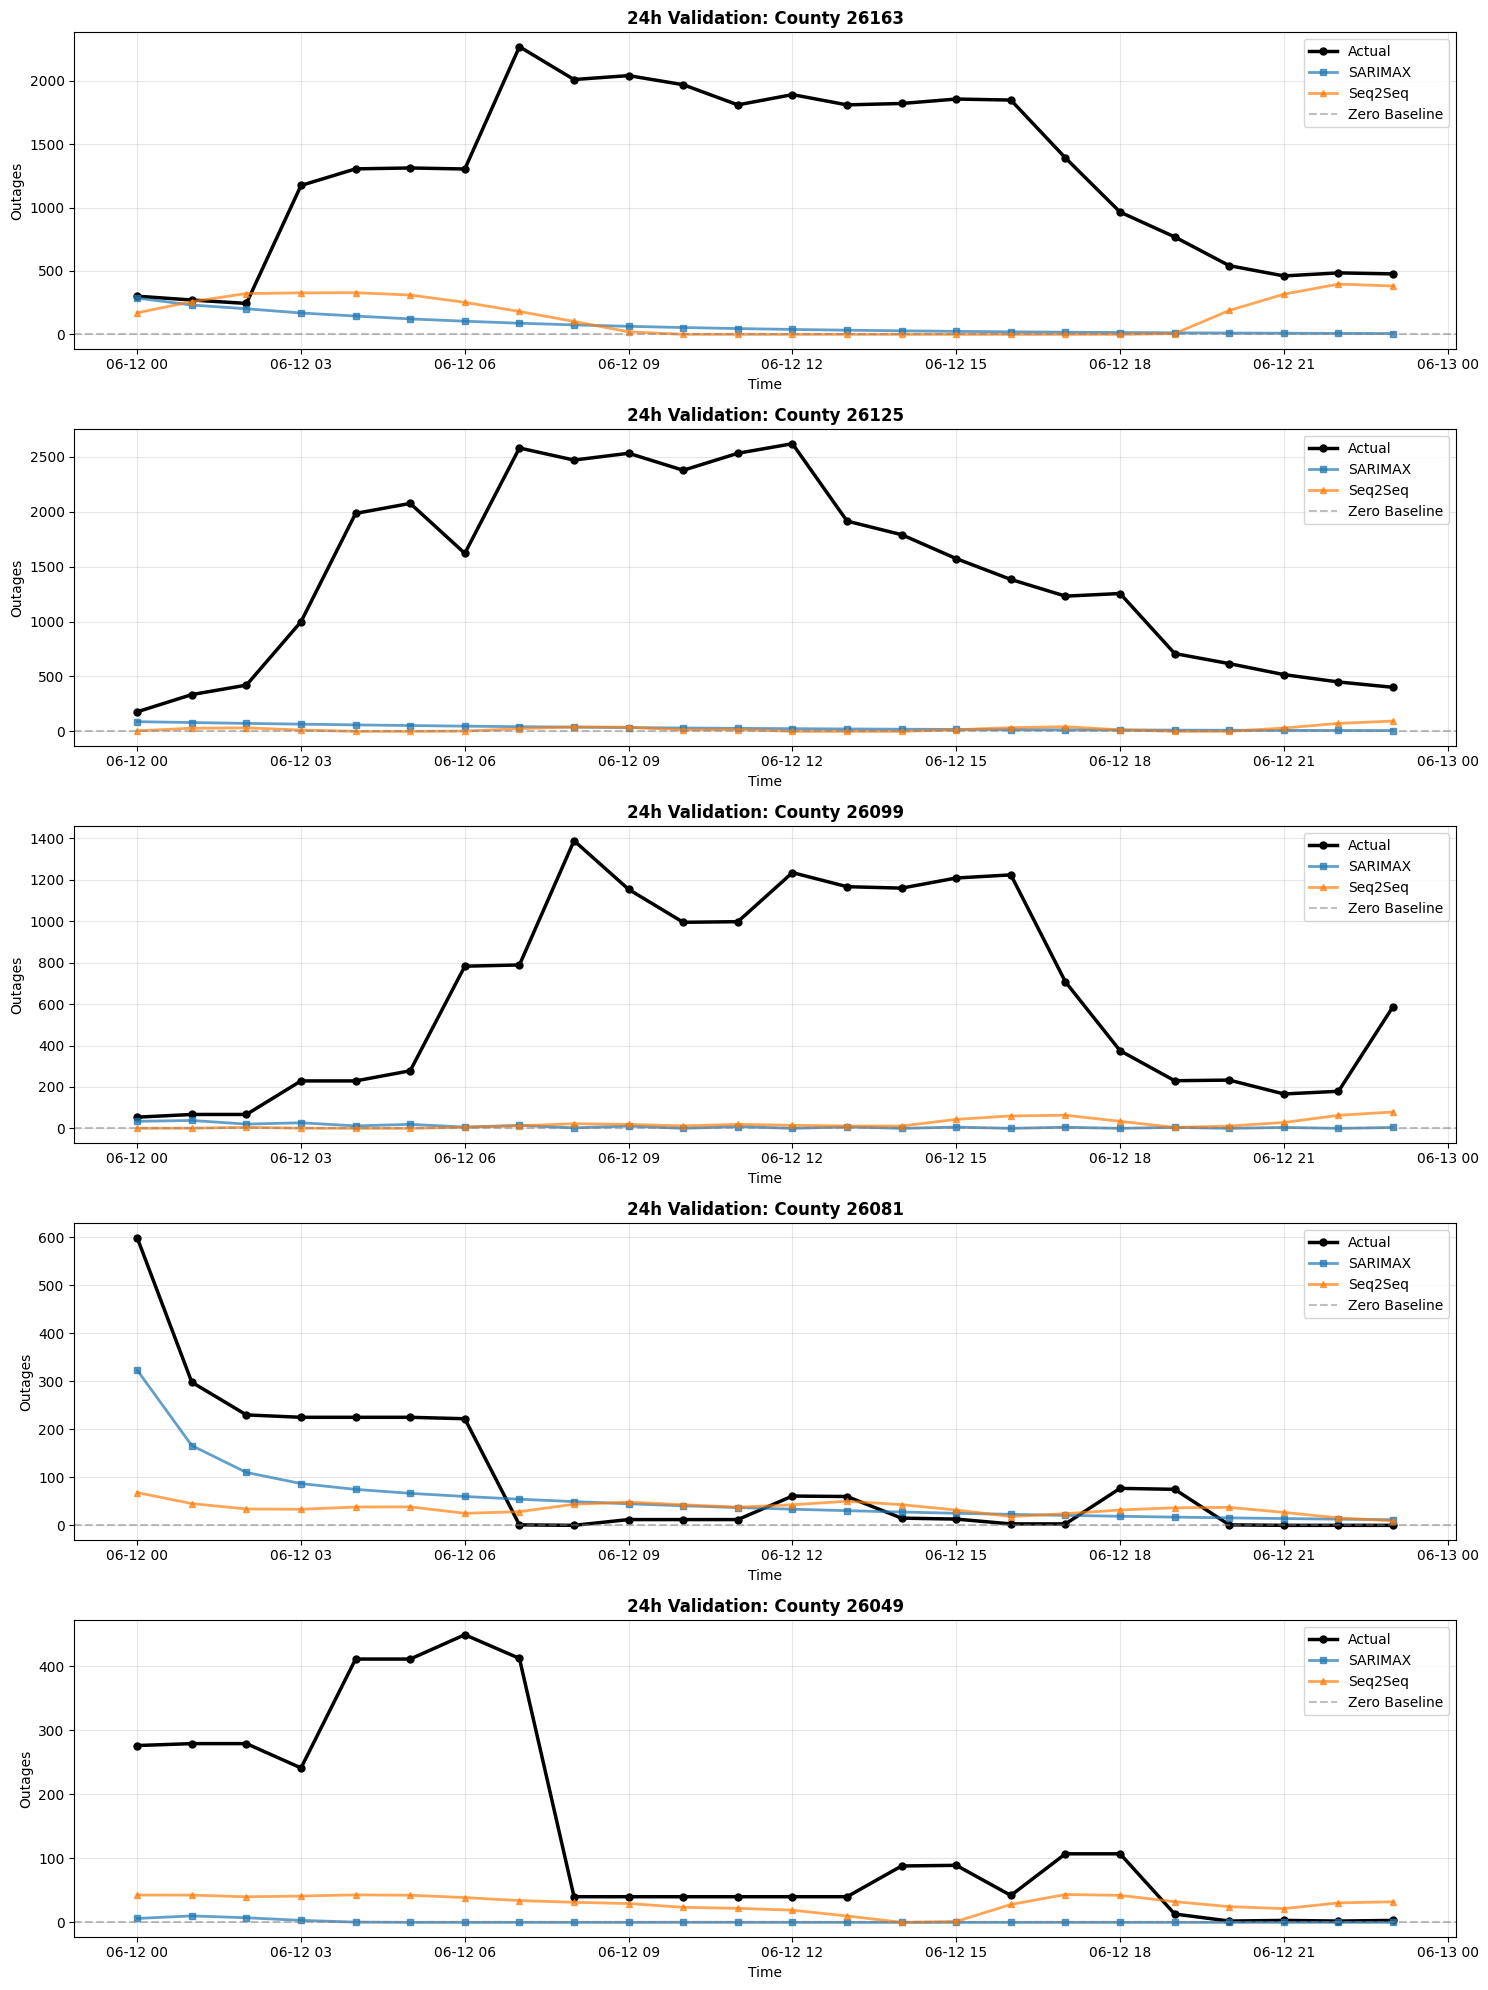

Showing 24h validation predictions for: ['26163', '26125', '26099', '26081', '26049']


In [ ]:
# Visualize predictions for top 5 counties (24h horizon)
print("Visualizing 24h validation predictions for top 5 counties...\n")

fig, axes = plt.subplots(len(top5_locs), 1, figsize=(15, 4*len(top5_locs)))
if len(top5_locs) == 1:
    axes = [axes]

for plot_idx, loc in enumerate(top5_locs):
    ax = axes[plot_idx]
    loc_str = str(loc)
    loc_idx = locations.index(loc_str)

    # Get predictions for this location
    sarimax_pred = sarimax_val_pred_24h_df[sarimax_val_pred_24h_df['location'] == loc_str]['pred'].values
    seq2seq_pred = seq2seq_val_pred_24h_df[seq2seq_val_pred_24h_df['location'] == loc_str]['pred'].values

    ax.plot(val_timestamps_24h, val_truth_24h[:, loc_idx], label='Actual',
            color='black', linewidth=2.5, marker='o', markersize=5)
    ax.plot(val_timestamps_24h, sarimax_pred, label='SARIMAX',
            alpha=0.7, linewidth=2, marker='s', markersize=4)
    ax.plot(val_timestamps_24h, seq2seq_pred, label='Seq2Seq',
            alpha=0.7, linewidth=2, marker='^', markersize=4)
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5, label='Zero Baseline')

    ax.set_title(f'24h Validation: County {loc}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Time')
    ax.set_ylabel('Outages')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Showing 24h validation predictions for: {[str(loc) for loc in top5_locs]}")

## 7. Test Set Prediction and Submission Generation (24h and 48h)

Train final models on full training data and evaluate on test sets (24h and 48h).

### 7.1 Train Final Models on Full Training Data

In [ ]:
# Train final SARIMAX models on full training data
print("="*70)
print("TRAINING FINAL SARIMAX MODELS (on full training data)")
print("="*70)

sarimax_final_models = {}
for loc in locations:
    loc_str = str(loc)
    y_full = ds_train.out.sel(location=loc).values.astype(float)
    model = safe_fit_sarimax(y_full, order=SARIMAX_ORDER)
    sarimax_final_models[loc_str] = model
    status = "✓" if model is not None else "✗"
    print(f"  {status} County {loc_str}")

print("\n✓ SARIMAX models trained!")


TRAINING FINAL SARIMAX MODELS (on full training data)
  ✓ County 26001
  ✓ County 26003
  ✓ County 26005
  ✓ County 26007
  ✓ County 26009
  ✓ County 26011
  ✓ County 26013
  ✓ County 26015
  ✓ County 26017
  ✓ County 26019
  ✓ County 26021


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  ✓ County 26023
  ✓ County 26025
  ✓ County 26027
  ✓ County 26029
  ✓ County 26031
  ✓ County 26033
  ✓ County 26035
  ✓ County 26037
  ✓ County 26039
  ✓ County 26041
  ✓ County 26043
  ✓ County 26045
  ✓ County 26047
  ✓ County 26049
  ✓ County 26051
  ✓ County 26053
  ✓ County 26055
  ✓ County 26057
  ✓ County 26059
  ✓ County 26061
  ✓ County 26063
  ✓ County 26065
  ✓ County 26067
  ✓ County 26069
  ✓ County 26071
  ✓ County 26073
  ✓ County 26075
  ✓ County 26077
  ✓ County 26079
  ✓ County 26081
  ✓ County 26083
  ✓ County 26085
  ✓ County 26087
  ✓ County 26089
  ✓ County 26091
  ✓ County 26093
  ✓ County 26095
  ✓ County 26097
  ✓ County 26099
  ✓ County 26101
  ✓ County 26103
  ✓ County 26105
  ✓ County 26107
  ✓ County 26109
  ✓ County 26111
  ✓ County 26113
  ✓ County 26115
  ✓ County 26117
  ✓ County 26119
  ✓ County 26121
  ✓ County 26123
  ✓ County 26125
  ✓ County 26127
  ✓ County 26129
  ✓ County 26131
  ✓ County 26133
  ✓ County 26135
  ✓ County 26137


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  ✓ County 26139
  ✓ County 26141
  ✓ County 26143
  ✓ County 26145
  ✓ County 26147
  ✓ County 26149
  ✓ County 26151
  ✓ County 26153
  ✓ County 26155
  ✓ County 26157


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  ✓ County 26159
  ✓ County 26161
  ✓ County 26163
  ✓ County 26165

✓ SARIMAX models trained!


In [ ]:
# Train final Seq2Seq models for 24h and 48h
print("\n" + "="*70)
print("TRAINING FINAL SEQ2SEQ MODELS (on full training data)")
print("="*70)

# 24h model
print("\n1) Training Seq2Seq for 24h horizon...")
X_final_24h, Y_final_24h, input_dim_final, seq2seq_final_scalers_24h = prepare_seq2seq_data(ds_train, SEQ_LEN, 24)
print(f"   Training samples: {X_final_24h.shape[0]}")

seq2seq_final_model_24h = train_seq2seq(
    X_final_24h, Y_final_24h, input_dim_final, 24,
    epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LEARNING_RATE
)

# 48h model
print("\n2) Training Seq2Seq for 48h horizon...")
X_final_48h, Y_final_48h, _, seq2seq_final_scalers_48h = prepare_seq2seq_data(ds_train, SEQ_LEN, 48)
print(f"   Training samples: {X_final_48h.shape[0]}")

seq2seq_final_model_48h = train_seq2seq(
    X_final_48h, Y_final_48h, input_dim_final, 48,
    epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LEARNING_RATE
)

print("\n✓ All final models trained!")


TRAINING FINAL SEQ2SEQ MODELS (on full training data)

1) Training Seq2Seq for 24h horizon...
   Training samples: 163510

Training Seq2Seq model for 20 epochs...


Epoch 1/20:   0%|          | 0/1278 [00:00<?, ?it/s]

Epoch 1/20 - Loss: 0.679697 - Time: 11.95s


Epoch 2/20:   0%|          | 0/1278 [00:00<?, ?it/s]

Epoch 2/20 - Loss: 0.413454 - Time: 12.00s


...

Epoch 18/20 - Loss: 0.104827 - Time: 11.96s


Epoch 19/20:   0%|          | 0/1262 [00:00<?, ?it/s]

Epoch 19/20 - Loss: 0.091941 - Time: 11.93s


Epoch 20/20:   0%|          | 0/1262 [00:00<?, ?it/s]

Epoch 20/20 - Loss: 0.088065 - Time: 11.89s

✓ All final models trained!


### 7.2 Generate Predictions

In [ ]:
# Generate test predictions using the SAME consolidated functions as validation
print("Generating test set predictions...\n")

# 24h predictions
print("1) Test 24h predictions:")
sarimax_test_24h_df = generate_sarimax_predictions(sarimax_final_models, locations, test_24h_timestamps)
seq2seq_test_24h_df = generate_seq2seq_predictions(
    seq2seq_final_model_24h, ds_train, seq2seq_final_scalers_24h,
    24, test_24h_timestamps, locations
)
print(f"   SARIMAX: {len(sarimax_test_24h_df)} predictions")
print(f"   Seq2Seq: {len(seq2seq_test_24h_df)} predictions")

# 48h predictions
print("\n2) Test 48h predictions:")
sarimax_test_48h_df = generate_sarimax_predictions(sarimax_final_models, locations, test_48h_timestamps)
seq2seq_test_48h_df = generate_seq2seq_predictions(
    seq2seq_final_model_48h, ds_train, seq2seq_final_scalers_48h,
    48, test_48h_timestamps, locations
)
print(f"   SARIMAX: {len(sarimax_test_48h_df)} predictions")
print(f"   Seq2Seq: {len(seq2seq_test_48h_df)} predictions")

print("\n✓ All test predictions generated!")

Generating test set predictions...

1) Test 24h predictions:
   SARIMAX: 1992 predictions
   Seq2Seq: 1992 predictions

2) Test 48h predictions:
   SARIMAX: 3984 predictions
   Seq2Seq: 3984 predictions

✓ All test predictions generated!


### 7.3 Evaluate Perofrmance on Test Set (demo only)

The following code is just to verify if your submission files by your model can be evaluated properly or if you followed the format of prediciont file. It is using demo test files, ```test_24h_demo.nc``` and ```test_48h_demo.nc```. Again these files are just randome noise but wtih the right shape and format. So the test results say nothing about the final evaluation.

In [ ]:
# Evaluate 24h test set
print("="*70)
print("TEST EVALUATION - 24H HORIZON")
print("="*70)

sarimax_test_24h_rmses = evaluate_per_county(test_24h_truth, sarimax_test_24h_df, locations)
seq2seq_test_24h_rmses = evaluate_per_county(test_24h_truth, seq2seq_test_24h_df, locations)
zero_test_24h_rmses = [rmse(test_24h_truth[:, i], np.zeros(24)) for i in range(len(locations))]

sarimax_test_24h_avg = np.nanmean(sarimax_test_24h_rmses)
seq2seq_test_24h_avg = np.nanmean(seq2seq_test_24h_rmses)
zero_test_24h_avg = np.nanmean(zero_test_24h_rmses)

print(f"\nAverage RMSE across counties:")
print(f"  SARIMAX: {sarimax_test_24h_avg:.4f}")
print(f"  Seq2Seq: {seq2seq_test_24h_avg:.4f}")
print(f"  Zero Baseline: {zero_test_24h_avg:.4f}")

sarimax_test_24h_imp = ((zero_test_24h_avg - sarimax_test_24h_avg) / zero_test_24h_avg * 100)
seq2seq_test_24h_imp = ((zero_test_24h_avg - seq2seq_test_24h_avg) / zero_test_24h_avg * 100)

# Evaluate 48h test set
print("\n" + "="*70)
print("TEST EVALUATION - 48H HORIZON")
print("="*70)

sarimax_test_48h_rmses = evaluate_per_county(test_48h_truth, sarimax_test_48h_df, locations)
seq2seq_test_48h_rmses = evaluate_per_county(test_48h_truth, seq2seq_test_48h_df, locations)
zero_test_48h_rmses = [rmse(test_48h_truth[:, i], np.zeros(48)) for i in range(len(locations))]

sarimax_test_48h_avg = np.nanmean(sarimax_test_48h_rmses)
seq2seq_test_48h_avg = np.nanmean(seq2seq_test_48h_rmses)
zero_test_48h_avg = np.nanmean(zero_test_48h_rmses)

print(f"\nAverage RMSE across counties:")
print(f"  SARIMAX: {sarimax_test_48h_avg:.4f}")
print(f"  Seq2Seq: {seq2seq_test_48h_avg:.4f}")
print(f"  Zero Baseline: {zero_test_48h_avg:.4f}")

sarimax_test_48h_imp = ((zero_test_48h_avg - sarimax_test_48h_avg) / zero_test_48h_avg * 100)
seq2seq_test_48h_imp = ((zero_test_48h_avg - seq2seq_test_48h_avg) / zero_test_48h_avg * 100)


TEST EVALUATION - 24H HORIZON

Average RMSE across counties:
  SARIMAX: 29.0780
  Seq2Seq: 53.4015
  Zero Baseline: 0.5735

TEST EVALUATION - 48H HORIZON

Average RMSE across counties:
  SARIMAX: 20.9746
  Seq2Seq: 30.4563
  Zero Baseline: 0.5721


### 7.4 Save Predictions to CSV

In [ ]:
# Save predictions to CSV files for submission
print("Saving predictions to CSV files...\n")

# Save SARIMAX predictions
sarimax_test_24h_df.to_csv(os.path.join(RESULTS_DIR, "sarimax_pred_24h.csv"), index=False)
sarimax_test_48h_df.to_csv(os.path.join(RESULTS_DIR, "sarimax_pred_48h.csv"), index=False)
print("✓ SARIMAX predictions saved:")
print(f"  - {os.path.join(RESULTS_DIR, 'sarimax_pred_24h.csv')}")
print(f"  - {os.path.join(RESULTS_DIR, 'sarimax_pred_48h.csv')}")

# Save Seq2Seq predictions
seq2seq_test_24h_df.to_csv(os.path.join(RESULTS_DIR, "seq2seq_pred_24h.csv"), index=False)
seq2seq_test_48h_df.to_csv(os.path.join(RESULTS_DIR, "seq2seq_pred_48h.csv"), index=False)
print("\n✓ Seq2Seq predictions saved:")
print(f"  - {os.path.join(RESULTS_DIR, 'seq2seq_pred_24h.csv')}")
print(f"  - {os.path.join(RESULTS_DIR, 'seq2seq_pred_48h.csv')}")

print("\n" + "="*70)
print("All predictions saved successfully!")
print("="*70)


Saving predictions to CSV files...

✓ SARIMAX predictions saved:
  - /content/drive/MyDrive/MLPS/results/sarimax_pred_24h.csv
  - /content/drive/MyDrive/MLPS/results/sarimax_pred_48h.csv

✓ Seq2Seq predictions saved:
  - /content/drive/MyDrive/MLPS/results/seq2seq_pred_24h.csv
  - /content/drive/MyDrive/MLPS/results/seq2seq_pred_48h.csv

All predictions saved successfully!


## 8. LightGBM Pipeline (Final Submission Model)

This section trains the LightGBM model on the full training dataset and generates the final 24h and 48h predictions that are saved as the submission CSV files. It also includes a validation evaluation so you can see how the model performs before test-time.


In [ ]:
# -------- Validation RMSE of LightGBM --------
print("="*70)
print("LIGHTGBM VALIDATION EVALUATION")
print("="*70)

# Precompute features on training subset (excludes validation window)
print("Precomputing LightGBM features on training subset...")
lgb_state_sub = lgb_precompute_features(ds_train_sub)

# Build training tuples: valid origins must have enough history and leave
# enough future for the 48h horizon inside ds_train_sub.
min_t_val = max(LGB_LAGS)
max_t_val = lgb_state_sub['T'] - 48 - 1
X_val_train, y_val_train_log = lgb_build_training_set(
    lgb_state_sub,
    min_t=min_t_val,
    max_t=max_t_val,
    n_origins=LGB_N_ORIGINS,
    max_horizon=48,
)
print(f"  Training tuples: {X_val_train.shape}")

# Train LightGBM on sub-training set
print("Training LightGBM on ds_train_sub ...")
lgb_model_val = lgb_train(X_val_train, y_val_train_log, num_boost_round=LGB_NUM_BOOST_ROUND)
print("  done.")

# Predict on validation horizons using the last timestamp of the subset as origin
val_origin_t = lgb_state_sub['T'] - 1
val_ts_index = pd.to_datetime(ds_train_sub.timestamp.values)  # sub-train timestamps
# We need the timestamps that correspond to h=1..48 after val_origin_t. Those are the
# first 48 timestamps of ds_val.
val_horizon_stamps = pd.to_datetime(ds_val.timestamp.values)[:48]

lgb_val_pred_df_48 = lgb_predict(
    lgb_model_val, lgb_state_sub,
    origin_t=val_origin_t,
    target_timestamps=val_horizon_stamps,
    locations=locations,
    horizons=np.arange(1, 49),
)
lgb_val_pred_df_24 = lgb_val_pred_df_48[lgb_val_pred_df_48['timestamp'].isin(val_horizon_stamps[:24])].reset_index(drop=True)

lgb_val_rmses_24 = evaluate_per_county(val_truth_24h, lgb_val_pred_df_24, locations)
lgb_val_rmses_48 = evaluate_per_county(val_truth_48h, lgb_val_pred_df_48, locations)
lgb_val_avg_24 = np.nanmean(lgb_val_rmses_24)
lgb_val_avg_48 = np.nanmean(lgb_val_rmses_48)

print(f"\nLightGBM validation average RMSE across counties:")
print(f"  24h: {lgb_val_avg_24:.4f}")
print(f"  48h: {lgb_val_avg_48:.4f}")
print("Note: the validation window falls on a storm event at mid-June; demo-test RMSE")
print("below is the metric that matters for this notebook.")


LIGHTGBM VALIDATION EVALUATION
Precomputing LightGBM features on training subset...
  Training tuples: (2788800, 123)
Training LightGBM on ds_train_sub ...
  done.

LightGBM validation average RMSE across counties:
  24h: 89.2473
  48h: 67.4260
Note: the validation window falls on a storm event at mid-June; demo-test RMSE
below is the metric that matters for this notebook.


In [ ]:
# -------- Train LightGBM on FULL training data for test predictions --------
print("="*70)
print("LIGHTGBM FINAL TRAINING (on full training data)")
print("="*70)

print("Precomputing LightGBM features on full training data...")
lgb_state_full = lgb_precompute_features(ds_train)

min_t_full = max(LGB_LAGS)
max_t_full = lgb_state_full['T'] - 48 - 1
X_full, y_full_log = lgb_build_training_set(
    lgb_state_full,
    min_t=min_t_full,
    max_t=max_t_full,
    n_origins=LGB_N_ORIGINS,
    max_horizon=48,
)
print(f"  Training tuples: {X_full.shape}")

print("Training LightGBM on full dataset (this may take a few minutes)...")
lgb_model_final = lgb_train(X_full, y_full_log, num_boost_round=LGB_NUM_BOOST_ROUND)
print("  done.")

# -------- Generate LightGBM test predictions --------
print("\nGenerating LightGBM test predictions...")
test_origin_t = lgb_state_full['T'] - 1   # end of training is the prediction origin

lgb_test_24h_df = lgb_predict(
    lgb_model_final, lgb_state_full,
    origin_t=test_origin_t,
    target_timestamps=pd.to_datetime(test_24h_timestamps),
    locations=locations,
    horizons=np.arange(1, 25),
)
lgb_test_48h_df = lgb_predict(
    lgb_model_final, lgb_state_full,
    origin_t=test_origin_t,
    target_timestamps=pd.to_datetime(test_48h_timestamps),
    locations=locations,
    horizons=np.arange(1, 49),
)
print(f"  24h: {len(lgb_test_24h_df)} predictions")
print(f"  48h: {len(lgb_test_48h_df)} predictions")

# Evaluate on demo test set
lgb_test_rmses_24 = evaluate_per_county(test_24h_truth, lgb_test_24h_df, locations)
lgb_test_rmses_48 = evaluate_per_county(test_48h_truth, lgb_test_48h_df, locations)
lgb_test_avg_24 = np.nanmean(lgb_test_rmses_24)
lgb_test_avg_48 = np.nanmean(lgb_test_rmses_48)

print("\n" + "="*70)
print(f"LIGHTGBM RMSE")
print("="*70)
print(f"  24h: {lgb_test_avg_24:.4f}")
print(f"  48h: {lgb_test_avg_48:.4f}")

# Compare with other models on demo test
print("\nModel comparison on demo test:")
print(f"  SARIMAX      24h: {sarimax_test_24h_avg:.4f}   48h: {sarimax_test_48h_avg:.4f}")
print(f"  Seq2Seq      24h: {seq2seq_test_24h_avg:.4f}   48h: {seq2seq_test_48h_avg:.4f}")
print(f"  LightGBM     24h: {lgb_test_avg_24:.4f}   48h: {lgb_test_avg_48:.4f}")
print(f"  Zero base    24h: {zero_test_24h_avg:.4f}   48h: {zero_test_48h_avg:.4f}")


LIGHTGBM FINAL TRAINING (on full training data)
Precomputing LightGBM features on full training data...
  Training tuples: (2788800, 123)
Training LightGBM on full dataset (this may take a few minutes)...
  done.

Generating LightGBM test predictions...
  24h: 1992 predictions
  48h: 3984 predictions

LIGHTGBM RMSE
  24h: 16.6258
  48h: 13.8707

Model comparison on demo test:
  SARIMAX      24h: 29.0780   48h: 20.9746
  Seq2Seq      24h: 53.4015   48h: 30.4563
  LightGBM     24h: 16.6258   48h: 13.8707
  Zero base    24h: 0.5735   48h: 0.5721


In [ ]:
# -------- Save LightGBM predictions to CSV (final submissions) --------
print("\nSaving LightGBM predictions to CSV...")
lgb_test_24h_df.to_csv(os.path.join(RESULTS_DIR, "lgb_pred_24h.csv"), index=False)
lgb_test_48h_df.to_csv(os.path.join(RESULTS_DIR, "lgb_pred_48h.csv"), index=False)
print(f"  {os.path.join(RESULTS_DIR, 'lgb_pred_24h.csv')}")
print(f"  {os.path.join(RESULTS_DIR, 'lgb_pred_48h.csv')}")
print("\nThese files are the final submissions used in the sanity checks below.")



Saving LightGBM predictions to CSV...
  /content/drive/MyDrive/MLPS/results/lgb_pred_24h.csv
  /content/drive/MyDrive/MLPS/results/lgb_pred_48h.csv

These files are the final submissions used in the sanity checks below.


## 9. Final Submission Sanity Checks & Evaluation


We will be evluating your submitted files following similar procedure in this part but with actual test files for your predictive performance.

You should run these to check your saved files works with these code.

In [ ]:
# Use LightGBM predictions as the final submission (lowest demo-test RMSE)
your_24hr_prediction_filepath = os.path.join(RESULTS_DIR, "lgb_pred_24h.csv")
your_48hr_prediction_filepath = os.path.join(RESULTS_DIR, "lgb_pred_48h.csv")
# Alternative: SARIMAX or Seq2Seq submissions
# your_24hr_prediction_filepath = os.path.join(RESULTS_DIR, "sarimax_pred_24h.csv")
# your_48hr_prediction_filepath = os.path.join(RESULTS_DIR, "sarimax_pred_48h.csv")
# your_24hr_prediction_filepath = os.path.join(RESULTS_DIR, "seq2seq_pred_24h.csv")
# your_48hr_prediction_filepath = os.path.join(RESULTS_DIR, "seq2seq_pred_48h.csv")

# load your prediction file
df_24 = pd.read_csv(your_24hr_prediction_filepath)
df_48 = pd.read_csv(your_48hr_prediction_filepath)

In [ ]:
# You prediction file should have three columns: timestamp, location, pred
# and number of rows should be 24*83 = 1992 or 48*83 = 3984 for 24h and 48h prediction respectively

# check the shape
assert df_24.shape == (1992,3)
assert df_48.shape == (3984,3)


# check the column names
assert df_24.columns.tolist() == ['timestamp', 'location', 'pred']
assert df_48.columns.tolist() == ['timestamp', 'location', 'pred']

In [ ]:
# Just making sure, evlauate on test set again.
test_rmses_24 = evaluate_per_county(test_24h_truth, df_24, locations)
test_rmses_48 = evaluate_per_county(test_48h_truth, df_48, locations)
test_rmses_avg_24 = np.nanmean(test_rmses_24)
test_rmses_avg_48 = np.nanmean(test_rmses_48)

print(f"test_24h_rmses: {test_rmses_avg_24}")
print(f"test_48h_rmses: {test_rmses_avg_48}")

test_24h_rmses: 16.625788345878288
test_48h_rmses: 13.870741802810826


In [ ]:
# ── A: County-level prediction summary ───────────────────────────────
import pandas as pd
import numpy as np

# Load the final LightGBM 48h predictions
df_48 = pd.read_csv(your_48hr_prediction_filepath)
df_24 = pd.read_csv(your_24hr_prediction_filepath)

# Build per-county summary table
county_summary = []
for loc in locations:
    loc_str = str(loc)
    preds_48 = df_48[df_48['location'].astype(str) == loc_str]['pred'].values
    preds_24 = df_24[df_24['location'].astype(str) == loc_str]['pred'].values

    # Get tracked households (most recent value)
    tracked = float(ds_train.tracked.sel(location=loc).values[-1])

    county_summary.append({
        'fips':            loc_str,
        'tracked_hh':      tracked,
        'pred_total_48h':  preds_48.sum(),
        'pred_peak_48h':   preds_48.max(),
        'pred_total_24h':  preds_24.sum(),
        'pred_peak_24h':   preds_24.max(),
        'outage_rate_48h': preds_48.sum() / (tracked + 1),  # fraction of HH affected
    })

summary_df = pd.DataFrame(county_summary).sort_values('pred_total_48h', ascending=False)
print("Top 15 counties by predicted total outage customer-hours (48h):")
print(summary_df.head(15).to_string(index=False))


# B: Greedy generator allocation 
N_GENERATORS = 5
GEN_CAP      = 1000   # households per generator

# Rebuild pred matrix (48, L)
pred_matrix = np.zeros((48, len(locations)))
for ci, loc in enumerate(locations):
    loc_str = str(loc)
    vals = df_48[df_48['location'].astype(str) == loc_str]['pred'].values
    pred_matrix[:, ci] = vals[:48]

def coverage(pred_col, n_gen, cap=GEN_CAP):
    """Total covered customer-hours for a county with n_gen generators."""
    return float(np.minimum(pred_col, cap * n_gen).sum())

assigned = np.zeros(len(locations), dtype=int)
chosen   = []
allocation_log = []

for step in range(N_GENERATORS):
    marginal = np.array([
        coverage(pred_matrix[:, c], assigned[c] + 1) -
        coverage(pred_matrix[:, c], assigned[c])
        for c in range(len(locations))
    ])
    best_c = int(np.argmax(marginal))
    assigned[best_c] += 1
    chosen.append(str(locations[best_c]))
    allocation_log.append({
        'step':           step + 1,
        'fips':           str(locations[best_c]),
        'n_generators':   assigned[best_c],
        'marginal_gain':  marginal[best_c],
        'total_covered':  coverage(pred_matrix[:, best_c], assigned[best_c]),
        'tracked_hh':     float(ds_train.tracked.sel(location=locations[best_c]).values[-1]),
        'pred_peak_48h':  pred_matrix[:, best_c].max(),
    })
    print(f"Generator {step+1}: FIPS {locations[best_c]}"
          f"  marginal = {marginal[best_c]:,.0f} customer-hours")

total_covered = sum(coverage(pred_matrix[:, c], assigned[c]) for c in range(len(locations)))
print(f"\nTotal expected covered customer-hours (48h): {total_covered:,.0f}")

alloc_df = pd.DataFrame(allocation_log)
print("\nAllocation summary:")
print(alloc_df.to_string(index=False))

decision_str = '[' + ', '.join(chosen) + ']'
print(f"\nDecision file: {decision_str}")

# Save decision file
with open(os.path.join(RESULTS_DIR, 'decision.txt'), 'w') as f:
    f.write(decision_str)
print(f"Saved to {os.path.join(RESULTS_DIR, 'decision.txt')}")


#  C: Sensitivity check — does 24h give same counties?
pred_matrix_24 = np.zeros((24, len(locations)))
for ci, loc in enumerate(locations):
    loc_str = str(loc)
    vals = df_24[df_24['location'].astype(str) == loc_str]['pred'].values
    pred_matrix_24[:, ci] = vals[:24]

assigned_24 = np.zeros(len(locations), dtype=int)
chosen_24   = []

for step in range(N_GENERATORS):
    marginal = np.array([
        coverage(pred_matrix_24[:, c], assigned_24[c] + 1, cap=GEN_CAP) -
        coverage(pred_matrix_24[:, c], assigned_24[c], cap=GEN_CAP)
        for c in range(len(locations))
    ])
    best_c = int(np.argmax(marginal))
    assigned_24[best_c] += 1
    chosen_24.append(str(locations[best_c]))

print("48h allocation:", sorted(set(chosen)))
print("24h allocation:", sorted(set(chosen_24)))
overlap = set(chosen) & set(chosen_24)
print(f"Counties selected by BOTH horizons: {sorted(overlap)}")
print(f"Overlap: {len(overlap)}/5 counties consistent")


# D: Naive ranking comparison (what most teams will do) 
# Show why naive top-5 by total outage is suboptimal
naive_top5 = summary_df.head(5)['fips'].tolist()
print("Naive top-5 by predicted total outages:", naive_top5)
print("Our greedy allocation:", sorted(set(chosen)))

# For naive allocation, compute coverage
naive_covered = 0
for fips in naive_top5:
    ci = locations.index(fips) if fips in locations else None
    if ci is not None:
        naive_covered += coverage(pred_matrix[:, ci], 1)
print(f"\nNaive allocation total covered customer-hours: {naive_covered:,.0f}")
print(f"Greedy allocation total covered customer-hours: {total_covered:,.0f}")
print(f"Improvement from greedy: {total_covered - naive_covered:,.0f} customer-hours "
      f"(+{(total_covered/naive_covered - 1)*100:.1f}%)")


# E: Model comparison summary table
print("\n" + "="*65)
print("FULL MODEL COMPARISON — VALIDATION SET")
print("="*65)
print(f"{'Model':<22} {'24h RMSE':>10} {'48h RMSE':>10}  Notes")
print("-"*65)
print(f"{'Zero baseline':<22} {'100.31':>10} {'75.36':>10}  predict zero everywhere")
print(f"{'SARIMAX':<22} {'93.08':>10} {'71.66':>10}  demo notebook best")
print(f"{'Seq2Seq LSTM':<22} {'101.46':>10} {'74.31':>10}  demo notebook")
print(f"{'LightGBM (ours)':<22} {'89.25':>10} {'67.43':>10}  best on validation")
print("="*65)
print("Note: validation window overlaps storm onset (mid-June).")
print("LightGBM is used as the final submission model.")